# FN
I am considering the following system

\begin{equation}
    \left\{\begin{aligned}
    &\dot{v} = v - \frac{v^3}{3} - w\\
    &\dot{w} = v - bw
    \end{aligned}\right.
\end{equation}

In [1]:
from functools import partial
from scipy.integrate import solve_ivp


import matplotlib.pyplot as plt
from matplotlib import rcParams, cycler
rcParams['axes.prop_cycle'] = cycler(color=plt.get_cmap('tab20').colors)
rcParams['text.usetex']=True
rcParams['font.family']='serif'

import numpy as np
rng = np.random.default_rng(seed=2025)


In [34]:
def free_RHS(t,x,b):
    v, w = x
    return (
        v - v**3/3 - w,
        v - b*w
    )

def plotter(axs, b, color, inset=False):
    '''c is color for the plots'''

    
    RHS = partial(free_RHS, b=b)

    # Upper plot
    ax = axs[0]
    res = solve_ivp(RHS, t_span=[0,100], y0=(0.5,0.5), method='LSODA')
    ax.plot(res.t, res.y[0], c=color, linewidth=1, label=r'$v$')
    ax.plot(res.t, res.y[1], c=color, linestyle='--', linewidth=1, label=r'$w$')
    ax.legend(frameon=False, ncols=2, loc=(0.05,1), markerscale=0.3, fontsize=10)
    
    ax.set_ymargin(0.2)
    ax.set_xlabel('Time')
    ax.set_title(r'$b = {}$'.format(b), y=1.6)

    # Lower plot
    y0s = rng.uniform(-3,3,size=(500,2))

    ax = axs[1]
    if inset:
        axins = ax.inset_axes(
            [0.6,0.1,0.3,0.3],
            xlim=(-0.2,.2), ylim=(-0.2,0.2),
            xticklabels=[],
            yticklabels=[]
        )


    for y0  in y0s:
        res = solve_ivp(RHS, t_span=[0,10], y0=y0, method='LSODA')
        ax.plot(res.y[0], res.y[1], linewidth=0.5, c=color, alpha=0.1)
        if inset: axins.plot(res.y[0], res.y[1], linewidth=0.5, c=color, alpha=0.1)

    # Nullclines
    X = np.linspace(-3,3,100)
    ax.plot(X, X - X**3/3, c='black', linewidth=1)
    ax.plot(X, X/b, c='black', linewidth=1)

    # Fixed points
    ax.scatter(0,0,s=20, c='black', zorder=20)
    if inset: axins.scatter(1,1, s=10, c='black', zorder=20)

    ax.set_xlim(-3,3)
    ax.set_ylim(-3,3)
    ax.set_xlabel(r'$v$')
    ax.set_ylabel(r'$w$')


    if inset: ax.indicate_inset_zoom(axins, edgecolor='black')



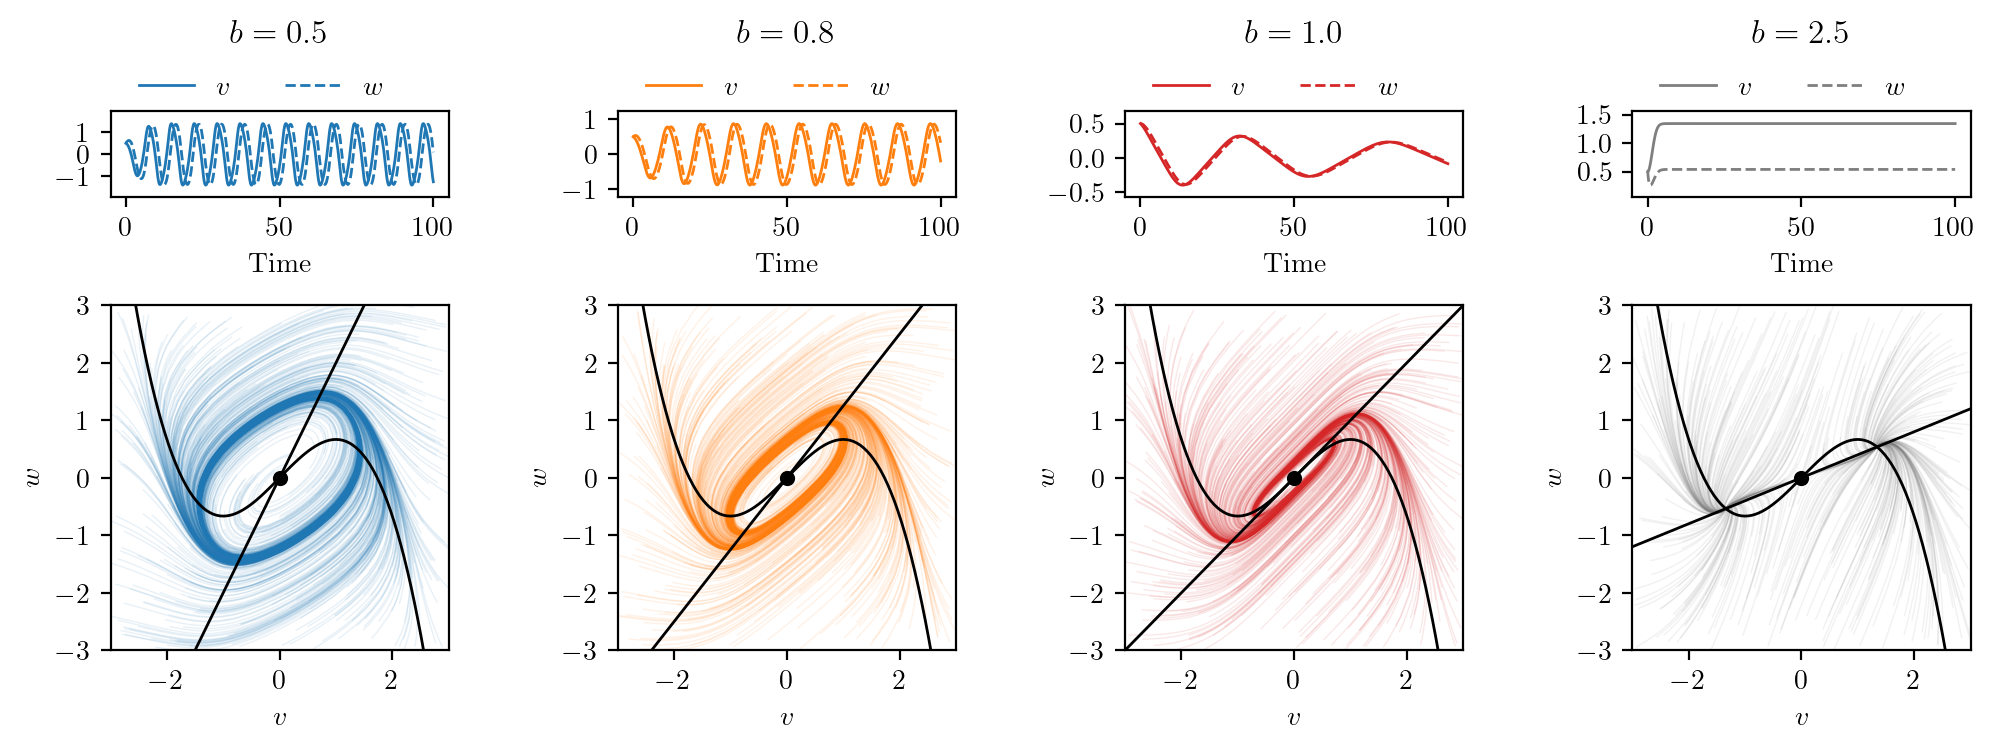

In [56]:
fig, axs = plt.subplots(2,4, height_ratios=(1,4), figsize=(12,3.5), dpi=200)
fig.subplots_adjust(wspace=0.5, hspace=0.5)

plotter(axs[:,0], b=0.5, color='tab:blue', inset=False)
plotter(axs[:,1], b=0.8, color='tab:orange', inset=False)
plotter(axs[:,2], b=1., color='tab:red', inset=False)
plotter(axs[:,3], b=2.5, color='tab:gray', inset=False)

In [99]:
np.isclose(1,np.linspace(0,10,11))

array([False,  True, False, False, False, False, False, False, False,
       False, False])

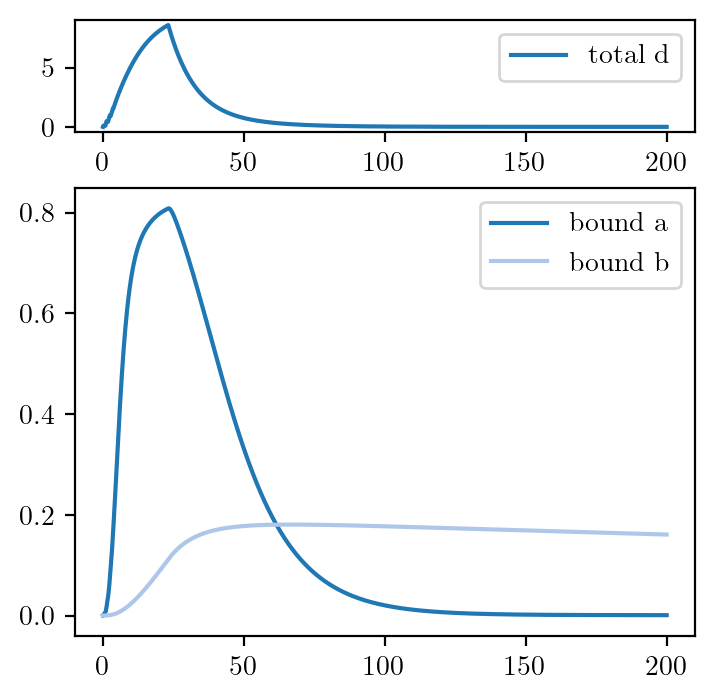

In [119]:
def spikes(t):
    if np.isclose(t,np.linspace(0,21,21), atol=1e-1, rtol=1e-1).any(): return 1
    else: return 0

def free_f(t,x,tau, k1,k2,k3,k4,A,B):
    d, a, b = x
    return (
        -d/tau - k1*(A-a)*d - k3*(B-b)*d + k2*a + k4*b + 1*spikes(t),
        k1*(A-a)*d - k2*a,
        k3*(B-b)*d - k4*b
    )

RHS = partial(
    free_f,
    tau=10,
    k1=.1,
    k2=.2,
    k3=.001,
    k4=.001,
    A = 1,
    B = 1,
)

res = solve_ivp(RHS, t_span=[0,200], y0=[0,0,0], method='LSODA', max_step=1e-1)


fig, axs = plt.subplots(2,1,figsize=(4,4), height_ratios=(1,4), dpi=200)

ax = axs[0]
ax.plot(res.t, res.y[0], label='total d')
ax.legend()

ax = axs[1]
ax.plot(res.t, res.y[1], label='bound a')
ax.plot(res.t, res.y[2], label='bound b')
# plt.plot(res.t, res.y[2], label='d')
ax.legend()